Epoch 1/50 | Train Loss: 1.8625 | Val Loss: 1.6054 | Val mIoU: 0.0610
Epoch 2/50 | Train Loss: 1.3812 | Val Loss: 1.3074 | Val mIoU: 0.1229
Epoch 3/50 | Train Loss: 1.2012 | Val Loss: 1.0932 | Val mIoU: 0.1824
Epoch 4/50 | Train Loss: 1.0357 | Val Loss: 1.5185 | Val mIoU: 0.1370
Epoch 5/50 | Train Loss: 0.9197 | Val Loss: 1.1505 | Val mIoU: 0.1881
Epoch 6/50 | Train Loss: 0.8527 | Val Loss: 0.9359 | Val mIoU: 0.1989
Epoch 7/50 | Train Loss: 0.7516 | Val Loss: 0.9801 | Val mIoU: 0.1944
Epoch 8/50 | Train Loss: 0.6541 | Val Loss: 1.2152 | Val mIoU: 0.2219
Epoch 9/50 | Train Loss: 0.6152 | Val Loss: 0.8168 | Val mIoU: 0.2392
Epoch 10/50 | Train Loss: 0.5952 | Val Loss: 1.2637 | Val mIoU: 0.2104
Epoch 11/50 | Train Loss: 0.5685 | Val Loss: 0.9030 | Val mIoU: 0.2296
Epoch 12/50 | Train Loss: 0.5511 | Val Loss: 0.6915 | Val mIoU: 0.2925
Epoch 13/50 | Train Loss: 0.5099 | Val Loss: 1.1548 | Val mIoU: 0.1612
Epoch 14/50 | Train Loss: 0.4670 | Val Loss: 1.0825 | Val mIoU: 0.2208
Epoch 15/50 | T

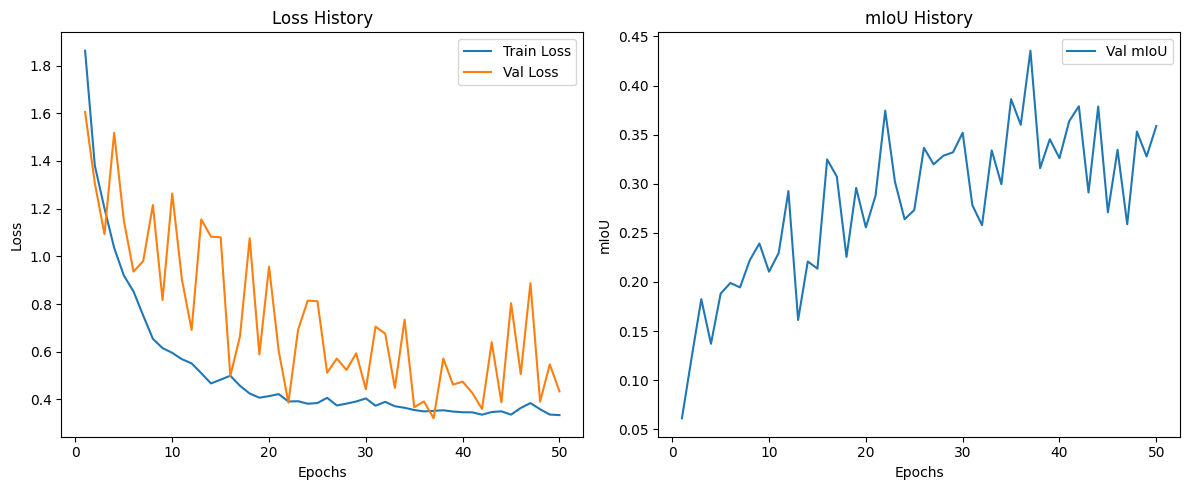


--- Test Evaluation ---
Test Loss: 0.4354
Overall Accuracy: 0.8230
Mean IoU (mIoU): 0.3582
F1-score: 0.5554
Per-class IoU: [4.60775037e-01 5.48373830e-01 5.89716029e-01 6.06719634e-01
 2.76084618e-02 1.80052957e-01 2.02438552e-01 2.51004592e-01
 6.19578686e-04 8.37804946e-01 8.23953824e-01 8.43415775e-01
 0.00000000e+00 0.00000000e+00 0.00000000e+00]


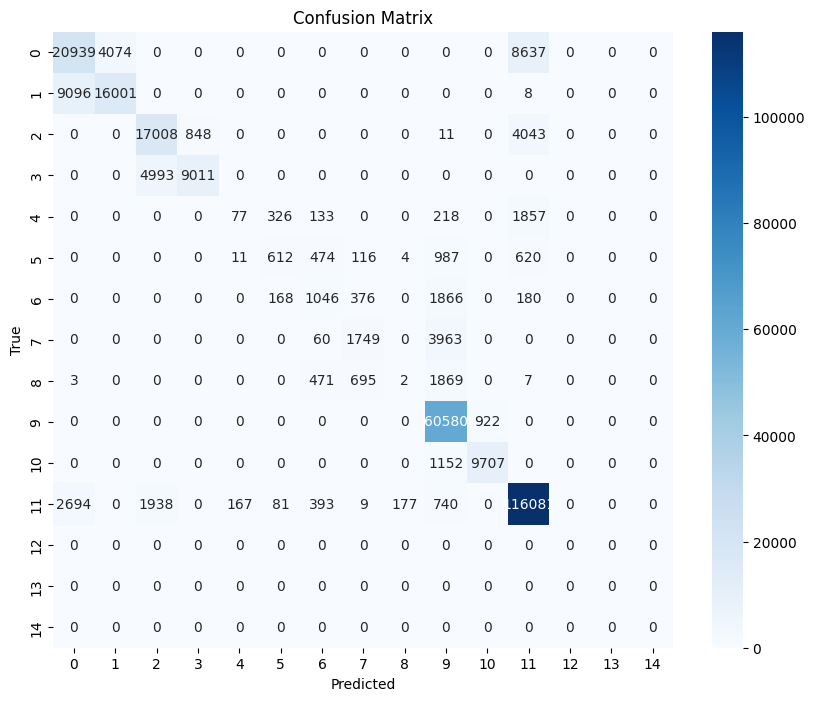

In [4]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from plyfile import PlyData
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class PointCloudDataset(Dataset):
    def __init__(self, file_paths, num_points=4096, augment=False):
        self.file_paths = file_paths
        self.num_points = num_points
        self.augment = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        plydata = PlyData.read(self.file_paths[idx])
        data = plydata.elements[0].data
        points = np.vstack([data['x'], data['y'], data['z']]).T
        labels = data['scalar_Label']

        centroid = np.mean(points, axis=0)
        points = points - centroid
        max_dist = np.max(np.sqrt(np.sum(points**2, axis=1)))
        if max_dist > 0:
            points = points / max_dist

        if len(points) > 0:
            choice = np.random.choice(len(points), self.num_points, replace=len(points) < self.num_points)
            points = points[choice]
            labels = labels[choice]
        else:
            points = np.zeros((self.num_points, 3))
            labels = np.zeros(self.num_points)

        if self.augment:
            theta = np.random.uniform(0, np.pi * 2)
            rotation_matrix = np.array([
                [np.cos(theta), -np.sin(theta), 0],
                [np.sin(theta), np.cos(theta), 0],
                [0, 0, 1]
            ])
            points = points.dot(rotation_matrix)
            noise = np.random.normal(0, 0.02, (self.num_points, 3))
            points += noise

        points = torch.tensor(points, dtype=torch.float32).transpose(0, 1)
        labels = torch.tensor(labels, dtype=torch.long)
        return points, labels

class SimplePointNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)
        self.conv4 = nn.Conv1d(1088, 512, 1)
        self.conv5 = nn.Conv1d(512, 256, 1)
        self.conv6 = nn.Conv1d(256, 128, 1)
        self.conv7 = nn.Conv1d(128, num_classes, 1)
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)
        self.bn6 = nn.BatchNorm1d(128)

    def forward(self, x):
        n_pts = x.size(2)
        x1 = self.relu(self.bn1(self.conv1(x)))
        x2 = self.relu(self.bn2(self.conv2(x1)))
        x3 = self.relu(self.bn3(self.conv3(x2)))
        global_feat = torch.max(x3, 2, keepdim=True)[0]
        global_feat = global_feat.view(-1, 1024, 1).repeat(1, 1, n_pts)
        concat_feat = torch.cat([x1, global_feat], 1)
        out = self.relu(self.bn4(self.conv4(concat_feat)))
        out = self.relu(self.bn5(self.conv5(out)))
        out = self.relu(self.bn6(self.conv6(out)))
        out = self.conv7(out)
        return out

def evaluate_model(loader, model, criterion, device, num_classes):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for points, labels in loader:
            points, labels = points.to(device), labels.to(device)
            outputs = model(points)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy().flatten()
            lbls = labels.cpu().numpy().flatten()
            all_preds.extend(preds)
            all_labels.extend(lbls)
            
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    iou_per_class = jaccard_score(all_labels, all_preds, average=None, labels=range(num_classes), zero_division=0)
    miou = np.mean(iou_per_class)
    cm = confusion_matrix(all_labels, all_preds, labels=range(num_classes))
    
    return total_loss / len(loader), acc, f1, miou, iou_per_class, cm

def plot_learning_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Loss History')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_miou'], label='Val mIoU')
    plt.title('mIoU History')
    plt.xlabel('Epochs')
    plt.ylabel('mIoU')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('learning_curves.png')
    plt.show()

def plot_confusion_matrix(cm, num_classes):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig('confusion_matrix.png')
    plt.show()

def starts():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    all_files = glob.glob('dataset/*.ply')
    

    train_files, test_val_files = train_test_split(all_files, test_size=0.3, random_state=42)
    val_files, test_files = train_test_split(test_val_files, test_size=0.5, random_state=42)

    train_loader = DataLoader(PointCloudDataset(train_files, augment=True), batch_size=8, shuffle=True)
    val_loader = DataLoader(PointCloudDataset(val_files, augment=False), batch_size=8, shuffle=False)
    test_loader = DataLoader(PointCloudDataset(test_files, augment=False), batch_size=8, shuffle=False)

    num_classes = 15 
    model = SimplePointNet(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'train_loss': [], 'val_loss': [], 'val_miou': []}
    epochs = 50

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for points, labels in train_loader:
            points, labels = points.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(points)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss_avg = train_loss / len(train_loader)
        val_loss, val_acc, val_f1, val_miou, _, _ = evaluate_model(val_loader, model, criterion, device, num_classes)
        
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss)
        history['val_miou'].append(val_miou)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss_avg:.4f} | Val Loss: {val_loss:.4f} | Val mIoU: {val_miou:.4f}")

    plot_learning_curves(history)

    print("\n--- Test Evaluation ---")
    test_loss, test_acc, test_f1, test_miou, test_iou_per_class, test_cm = evaluate_model(test_loader, model, criterion, device, num_classes)
    
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Overall Accuracy: {test_acc:.4f}")
    print(f"Mean IoU (mIoU): {test_miou:.4f}")
    print(f"F1-score: {test_f1:.4f}")
    print(f"Per-class IoU: {test_iou_per_class}")
    
    plot_confusion_matrix(test_cm, num_classes)

starts()

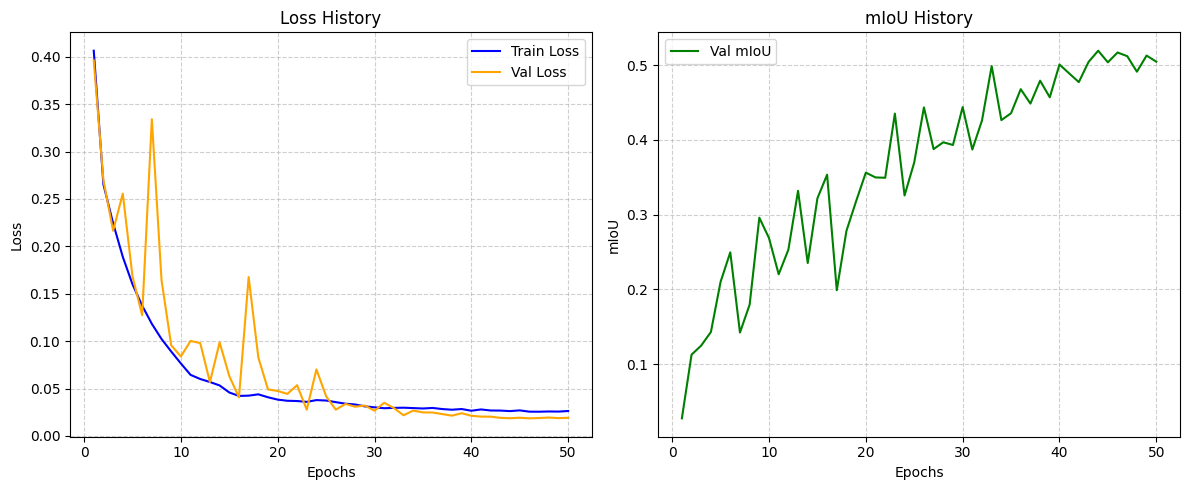

Test Loss: 0.0197
Overall Accuracy: 0.9127
Mean IoU (mIoU): 0.5021
F1-score: 0.7317
Per-class IoU: 
[0.6968699  0.77549705 0.78027963 0.81975814 0.35879158 0.29544731
 0.38255287 0.5218859  0.10484608 0.95226686 0.91076923 0.93288755
 0.         0.         0.        ]


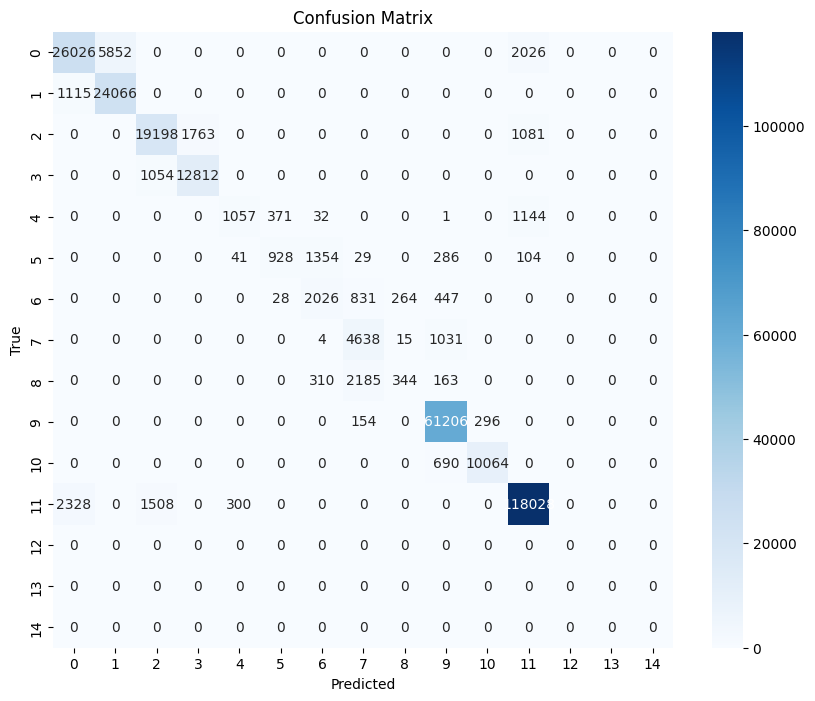

In [5]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from plyfile import PlyData
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output

class PointCloudDataset(Dataset):
    def __init__(self, file_paths, num_points=4096, augment=False):
        self.file_paths = file_paths
        self.num_points = num_points
        self.augment = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        plydata = PlyData.read(self.file_paths[idx])
        data = plydata.elements[0].data
        points = np.vstack([data['x'], data['y'], data['z']]).T
        labels = data['scalar_Label']

        centroid = np.mean(points, axis=0)
        points = points - centroid
        max_dist = np.max(np.sqrt(np.sum(points**2, axis=1)))
        if max_dist > 0:
            points = points / max_dist

        if len(points) > 0:
            choice = np.random.choice(len(points), self.num_points, replace=len(points) < self.num_points)
            points = points[choice]
            labels = labels[choice]
        else:
            points = np.zeros((self.num_points, 3))
            labels = np.zeros(self.num_points)

        if self.augment:
            theta = np.random.uniform(0, np.pi * 2)
            rotation_matrix = np.array([
                [np.cos(theta), -np.sin(theta), 0],
                [np.sin(theta), np.cos(theta), 0],
                [0, 0, 1]
            ])
            points = points.dot(rotation_matrix)
            noise = np.random.normal(0, 0.015, (self.num_points, 3))
            points += noise

        points = torch.tensor(points, dtype=torch.float32).transpose(0, 1)
        labels = torch.tensor(labels, dtype=torch.long)
        return points, labels

class SimplePointNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)
        self.conv4 = nn.Conv1d(1088, 512, 1)
        self.conv5 = nn.Conv1d(512, 256, 1)
        self.conv6 = nn.Conv1d(256, 128, 1)
        self.conv7 = nn.Conv1d(128, num_classes, 1)
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)
        self.bn6 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        n_pts = x.size(2)
        x1 = self.relu(self.bn1(self.conv1(x)))
        x2 = self.relu(self.bn2(self.conv2(x1)))
        x3 = self.relu(self.bn3(self.conv3(x2)))
        global_feat = torch.max(x3, 2, keepdim=True)[0]
        global_feat = global_feat.view(-1, 1024, 1).repeat(1, 1, n_pts)
        concat_feat = torch.cat([x1, global_feat], 1)
        out = self.relu(self.bn4(self.conv4(concat_feat)))
        out = self.relu(self.bn5(self.conv5(out)))
        out = self.relu(self.bn6(self.conv6(out)))
        out = self.dropout(out)
        out = self.conv7(out)
        return out

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

def evaluate_model(loader, model, criterion, device, num_classes):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for points, labels in loader:
            points, labels = points.to(device), labels.to(device)
            outputs = model(points)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy().flatten()
            lbls = labels.cpu().numpy().flatten()
            all_preds.extend(preds)
            all_labels.extend(lbls)
            
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    iou_per_class = jaccard_score(all_labels, all_preds, average=None, labels=range(num_classes), zero_division=0)
    miou = np.mean(iou_per_class)
    cm = confusion_matrix(all_labels, all_preds, labels=range(num_classes))
    
    return total_loss / len(loader), acc, f1, miou, iou_per_class, cm

def plot_learning_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', color='blue')
    plt.plot(epochs, history['val_loss'], label='Val Loss', color='orange')
    plt.title('Loss History')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_miou'], label='Val mIoU', color='green')
    plt.title('mIoU History')
    plt.xlabel('Epochs')
    plt.ylabel('mIoU')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, num_classes):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

def starts():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    all_files = glob.glob('dataset/*.ply')


    train_files, test_val_files = train_test_split(all_files, test_size=0.3, random_state=42)
    val_files, test_files = train_test_split(test_val_files, test_size=0.5, random_state=42)

    train_loader = DataLoader(PointCloudDataset(train_files, augment=True), batch_size=16, shuffle=True)
    val_loader = DataLoader(PointCloudDataset(val_files, augment=False), batch_size=16, shuffle=False)
    test_loader = DataLoader(PointCloudDataset(test_files, augment=False), batch_size=16, shuffle=False)

    num_classes = 15 
    model = SimplePointNet(num_classes).to(device)
    
    criterion = FocalLoss(gamma=2.0, alpha=0.25)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    epochs = 50
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    history = {'train_loss': [], 'val_loss': [], 'val_miou': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for points, labels in train_loader:
            points, labels = points.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(points)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        train_loss_avg = train_loss / len(train_loader)
        val_loss, val_acc, val_f1, val_miou, _, _ = evaluate_model(val_loader, model, criterion, device, num_classes)
        
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss)
        history['val_miou'].append(val_miou)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss_avg:.4f} | Val Loss: {val_loss:.4f} | Val mIoU: {val_miou:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    clear_output(wait=True)
    
    plot_learning_curves(history)

    test_loss, test_acc, test_f1, test_miou, test_iou_per_class, test_cm = evaluate_model(test_loader, model, criterion, device, num_classes)
    
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Overall Accuracy: {test_acc:.4f}")
    print(f"Mean IoU (mIoU): {test_miou:.4f}")
    print(f"F1-score: {test_f1:.4f}")
    print(f"Per-class IoU: \n{test_iou_per_class}")
    
    plot_confusion_matrix(test_cm, num_classes)
starts()

RuntimeError: Given groups=1, weight of size [512, 1600, 1], expected input[8, 2112, 2048] to have 1600 channels, but got 2112 channels instead

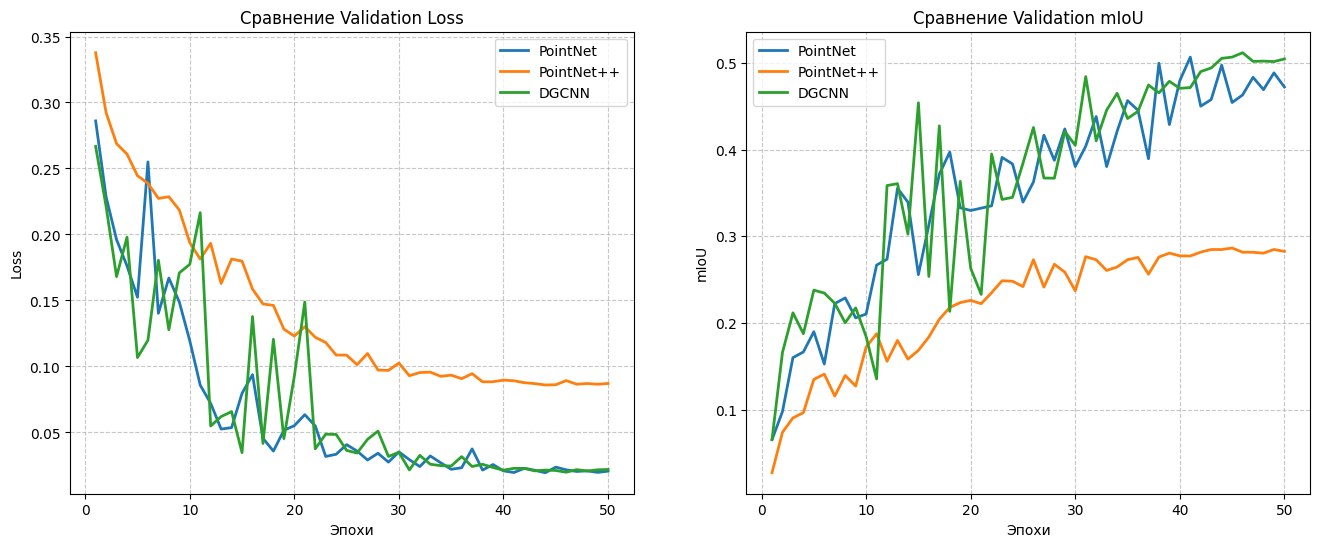


Генерация 3D-визуализации для сравнения...


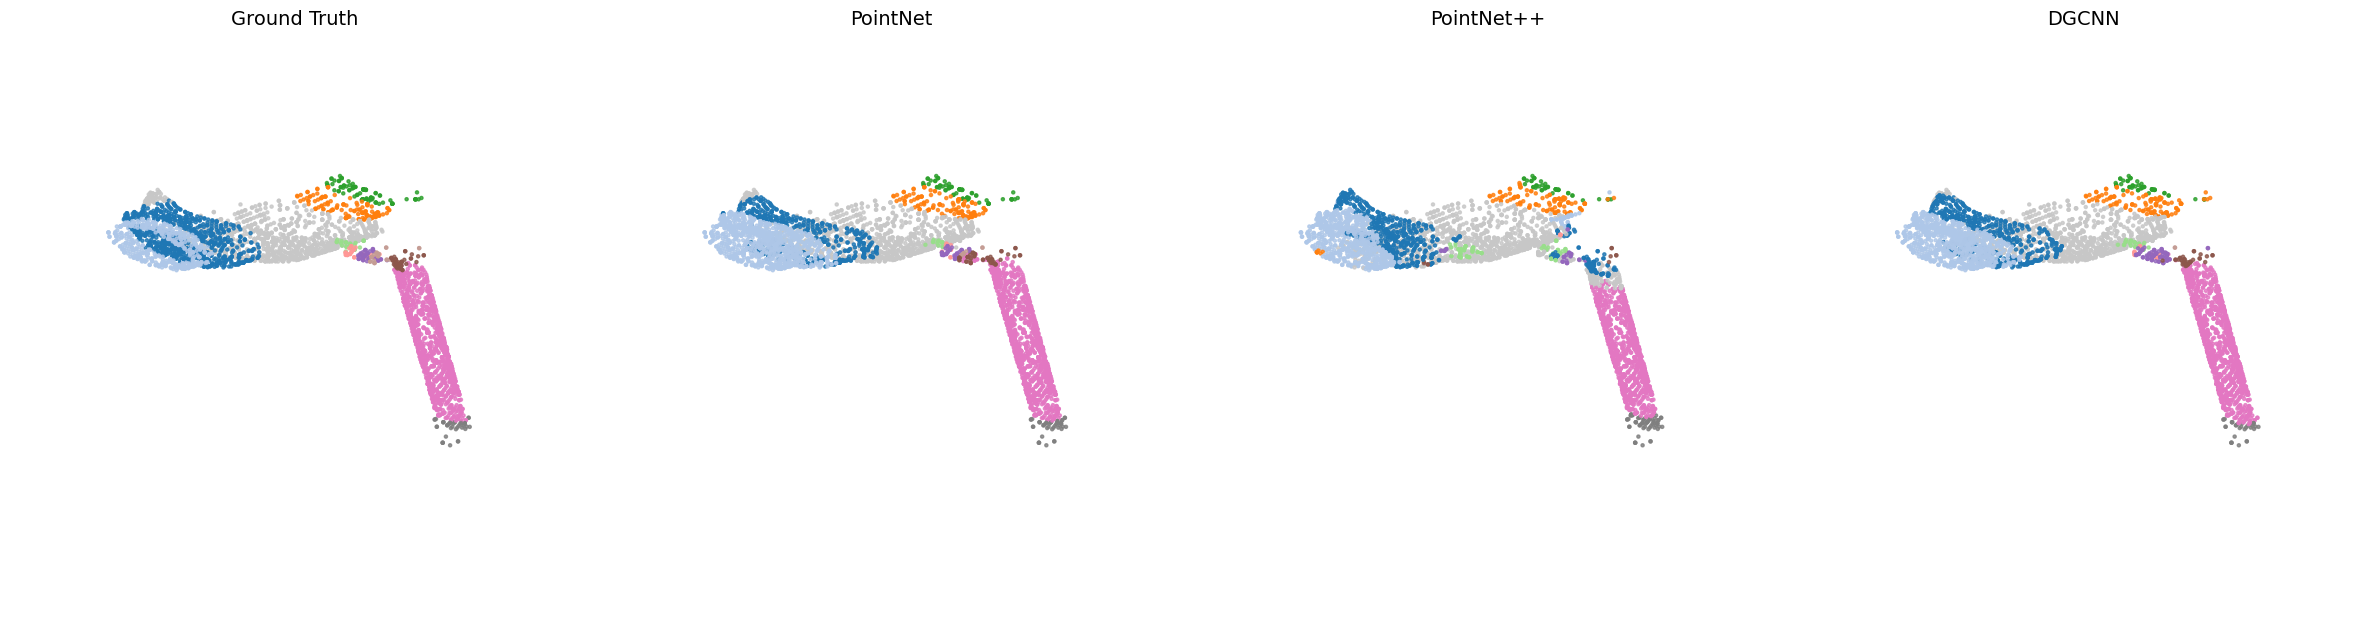

In [8]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from plyfile import PlyData
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, jaccard_score
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output

class PointCloudDataset(Dataset):
    def __init__(self, file_paths, num_points=4096, augment=False):
        self.file_paths = file_paths
        self.num_points = num_points
        self.augment = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        plydata = PlyData.read(self.file_paths[idx])
        data = plydata.elements[0].data
        points = np.vstack([data['x'], data['y'], data['z']]).T
        labels = data['scalar_Label']

        centroid = np.mean(points, axis=0)
        points = points - centroid
        max_dist = np.max(np.sqrt(np.sum(points**2, axis=1)))
        if max_dist > 0:
            points = points / max_dist

        if len(points) > 0:
            choice = np.random.choice(len(points), self.num_points, replace=len(points) < self.num_points)
            points = points[choice]
            labels = labels[choice]
        else:
            points = np.zeros((self.num_points, 3))
            labels = np.zeros(self.num_points)

        if self.augment:
            theta = np.random.uniform(0, np.pi * 2)
            rotation_matrix = np.array([
                [np.cos(theta), -np.sin(theta), 0],
                [np.sin(theta), np.cos(theta), 0],
                [0, 0, 1]
            ])
            points = points.dot(rotation_matrix)
            noise = np.random.normal(0, 0.015, (self.num_points, 3))
            points += noise

        points = torch.tensor(points, dtype=torch.float32).transpose(0, 1)
        labels = torch.tensor(labels, dtype=torch.long)
        return points, labels

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

class PointNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)
        self.conv4 = nn.Conv1d(1088, 512, 1)
        self.conv5 = nn.Conv1d(512, 256, 1)
        self.conv6 = nn.Conv1d(256, 128, 1)
        self.conv7 = nn.Conv1d(128, num_classes, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)
        self.bn6 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        n_pts = x.size(2)
        x1 = F.relu(self.bn1(self.conv1(x)))
        x2 = F.relu(self.bn2(self.conv2(x1)))
        x3 = F.relu(self.bn3(self.conv3(x2)))
        global_feat = torch.max(x3, 2, keepdim=True)[0]
        global_feat = global_feat.view(-1, 1024, 1).repeat(1, 1, n_pts)
        concat_feat = torch.cat([x1, global_feat], 1)
        out = F.relu(self.bn4(self.conv4(concat_feat)))
        out = F.relu(self.bn5(self.conv5(out)))
        out = F.relu(self.bn6(self.conv6(out)))
        out = self.dropout(out)
        out = self.conv7(out)
        return out

def fps(xyz, npoint):
    device = xyz.device
    B, N, _ = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long).to(device)
    distance = torch.ones(B, N).to(device) * 1e10
    farthest = torch.randint(0, N, (B,), dtype=torch.long).to(device)
    batch_indices = torch.arange(B, dtype=torch.long).to(device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_indices, farthest, :].view(B, 1, 3)
        dist = torch.sum((xyz - centroid) ** 2, -1)
        mask = dist < distance
        distance[mask] = dist[mask]
        farthest = torch.max(distance, -1)[1]
    return centroids

def index_points(points, idx):
    device = points.device
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = torch.arange(B, dtype=torch.long).to(device).view(view_shape).repeat(repeat_shape)
    new_points = points[batch_indices, idx, :]
    return new_points

class SimplifiedPointNetPlusPlus(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 512, 1)
        
        self.conv4 = nn.Conv1d(515, 256, 1)
        self.conv5 = nn.Conv1d(256, 512, 1)
        self.conv6 = nn.Conv1d(512, 1024, 1)
        
        self.conv7 = nn.Conv1d(2112, 512, 1)
        self.conv8 = nn.Conv1d(512, 256, 1)
        self.conv9 = nn.Conv1d(256, num_classes, 1)

    def forward(self, x):
        B, C, N = x.shape
        xyz = x.transpose(1, 2)
        
        l1_x = F.relu(self.conv1(x))
        l1_x = F.relu(self.conv2(l1_x))
        l1_x = F.relu(self.conv3(l1_x))
        
        fps_idx = fps(xyz, N // 4)
        new_xyz = index_points(xyz, fps_idx)
        
        dist = torch.cdist(xyz, new_xyz)
        _, nn_idx = torch.topk(dist, k=1, dim=-1, largest=False)
        nn_idx = nn_idx.squeeze(-1)
        
        pooled_feat = torch.zeros(B, 512, N // 4, device=x.device)
        pooled_feat.scatter_add_(2, nn_idx.unsqueeze(1).expand(-1, 512, -1), l1_x)
        
        l2_input = torch.cat([new_xyz.transpose(1, 2), pooled_feat], dim=1)
        l2_x = F.relu(self.conv4(l2_input))
        l2_x = F.relu(self.conv5(l2_x))
        l2_x = F.relu(self.conv6(l2_x))
        
        global_feat = torch.max(l2_x, 2, keepdim=True)[0]
        global_feat = global_feat.repeat(1, 1, N)
        
        up_feat = index_points(l2_x.transpose(1, 2), nn_idx).transpose(1, 2)
        
        concat_feat = torch.cat([global_feat, up_feat, F.relu(self.conv1(x))], dim=1)
        out = F.relu(self.conv7(concat_feat))
        out = F.relu(self.conv8(out))
        out = self.conv9(out)
        return out

def knn(x, k):
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    idx = pairwise_distance.topk(k=k, dim=-1)[1]
    return idx

def get_graph_feature(x, k=20, idx=None):
    batch_size = x.size(0)
    num_points = x.size(2)
    x = x.view(batch_size, -1, num_points)
    if idx is None:
        idx = knn(x, k=k)
    device = x.device
    idx_base = torch.arange(0, batch_size, device=device).view(-1, 1, 1) * num_points
    idx = idx + idx_base
    idx = idx.view(-1)
    _, num_dims, _ = x.size()
    x = x.transpose(2, 1).contiguous()
    feature = x.view(batch_size * num_points, -1)[idx, :]
    feature = feature.view(batch_size, num_points, k, num_dims)
    x = x.view(batch_size, num_points, 1, num_dims).repeat(1, 1, k, 1)
    feature = torch.cat((feature - x, x), dim=3).permute(0, 3, 1, 2).contiguous()
    return feature

class DGCNN(nn.Module):
    def __init__(self, num_classes, k=20):
        super().__init__()
        self.k = k
        self.conv1 = nn.Sequential(nn.Conv2d(6, 64, 1), nn.BatchNorm2d(64), nn.ReLU())
        self.conv2 = nn.Sequential(nn.Conv2d(128, 64, 1), nn.BatchNorm2d(64), nn.ReLU())
        self.conv3 = nn.Sequential(nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024), nn.ReLU())
        self.conv4 = nn.Sequential(nn.Conv1d(1152, 512, 1), nn.BatchNorm1d(512), nn.ReLU())
        self.conv5 = nn.Sequential(nn.Conv1d(512, 256, 1), nn.BatchNorm1d(256), nn.ReLU())
        self.conv6 = nn.Conv1d(256, num_classes, 1)

    def forward(self, x):
        n_pts = x.size(2)
        x = get_graph_feature(x, k=self.k)
        x = self.conv1(x)
        x1 = x.max(dim=-1, keepdim=False)[0]

        x = get_graph_feature(x1, k=self.k)
        x = self.conv2(x)
        x2 = x.max(dim=-1, keepdim=False)[0]

        x = torch.cat((x1, x2), dim=1)
        x3 = self.conv3(x)
        
        global_feat = x3.max(dim=-1, keepdim=True)[0]
        global_feat = global_feat.repeat(1, 1, n_pts)
        
        x = torch.cat((x, global_feat), dim=1)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        return x

def evaluate_model(loader, model, criterion, device, num_classes):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for points, labels in loader:
            points, labels = points.to(device), labels.to(device)
            outputs = model(points)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy().flatten()
            lbls = labels.cpu().numpy().flatten()
            all_preds.extend(preds)
            all_labels.extend(lbls)
            
    acc = accuracy_score(all_labels, all_preds)
    miou = np.mean(jaccard_score(all_labels, all_preds, average=None, labels=range(num_classes), zero_division=0))
    return total_loss / len(loader), acc, miou

def visualize_3d_comparison(test_loader, models, device, num_classes):
    points, labels = next(iter(test_loader))
    pts = points[0].cpu().numpy().T
    lbl = labels[0].cpu().numpy()
    
    preds = {}
    for name, model in models.items():
        model.eval()
        with torch.no_grad():
            out = model(points.to(device))
            preds[name] = torch.argmax(out[0], dim=0).cpu().numpy()
            
    fig = plt.figure(figsize=(24, 6))
    titles = ['Ground Truth'] + list(models.keys())
    data_list = [lbl] + [preds[name] for name in models.keys()]
    cmap = plt.get_cmap("tab20")
    
    for i, (title, data) in enumerate(zip(titles, data_list)):
        ax = fig.add_subplot(1, 4, i+1, projection='3d')
        colors = cmap(data / (num_classes - 1))
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=colors, s=5, alpha=0.8)
        ax.set_title(title, fontsize=14, pad=10)
        ax.axis('off')
        
        ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    plt.show()

def run_experiment():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Используемое устройство: {device}")
    
    all_files = glob.glob('dataset/*.ply')


    train_files, test_val_files = train_test_split(all_files, test_size=0.3, random_state=42)
    val_files, test_files = train_test_split(test_val_files, test_size=0.5, random_state=42)

    train_loader = DataLoader(PointCloudDataset(train_files, num_points=4096, augment=True), batch_size=8, shuffle=True)
    val_loader = DataLoader(PointCloudDataset(val_files, num_points=4096, augment=False), batch_size=8, shuffle=False)
    test_loader = DataLoader(PointCloudDataset(test_files, num_points=4096, augment=False), batch_size=1, shuffle=False)

    num_classes = 15 
    epochs = 50
    criterion = FocalLoss()
    
    models = {
        'PointNet': PointNet(num_classes).to(device),
        'PointNet++': SimplifiedPointNetPlusPlus(num_classes).to(device),
        'DGCNN': DGCNN(num_classes).to(device)
    }
    
    results = {name: {'loss': [], 'miou': []} for name in models.keys()}

    for name, model in models.items():
        print(f"\n--- Начало обучения модели: {name} ---")
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        
        for epoch in range(epochs):
            model.train()
            train_loss = 0
            for points, labels in train_loader:
                points, labels = points.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(points)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
                
            scheduler.step()
            val_loss, val_acc, val_miou = evaluate_model(val_loader, model, criterion, device, num_classes)
            results[name]['loss'].append(val_loss)
            results[name]['miou'].append(val_miou)
            
            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"[{name}] Эпоха {epoch+1}/{epochs} | Val Loss: {val_loss:.4f} | Val mIoU: {val_miou:.4f}")
            
    clear_output(wait=True)
    
    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    for name in models.keys():
        plt.plot(range(1, epochs + 1), results[name]['loss'], label=name, linewidth=2)
    plt.title('Сравнение Validation Loss')
    plt.xlabel('Эпохи')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.subplot(1, 2, 2)
    for name in models.keys():
        plt.plot(range(1, epochs + 1), results[name]['miou'], label=name, linewidth=2)
    plt.title('Сравнение Validation mIoU')
    plt.xlabel('Эпохи')
    plt.ylabel('mIoU')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    visualize_3d_comparison(test_loader, models, device, num_classes)

run_experiment()